<a href="https://colab.research.google.com/github/Shavindri/Data-Analytics-and-Visualization/blob/Masters/20336291_Data_Analytics_Visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student : Shavindri Kuweju

Student number : 20336291

Module code : DAS7000

Dataset: https://data.cdc.gov/api/views/mpx5-t7tu/rows.csv?accessType=DOWNLOAD

# **Dataset Overview**

---



The US Centres for Disease Control and Prevention (CDC) provided the dataset used in this analysis, which offers comprehensive data on COVID-19 deaths nationwide. The dataset comprises characteristics such as death counts, crude death rates, reporting periods, demographic groups, and geographical identifiers. This type of public-health dataset is highly significant for corporate, government, and healthcare decision-making, particularly in areas such as hospital resource planning, medical supply distribution, and projecting health-service demand.

The purpose of this job is to apply data analytics techniques using Python to analyse the quality of the dataset, perform preprocessing to handle typical issues such as missing values and outliers, and provide meaningful exploratory data analysis (EDA). By investigating trends, correlations, regional disparities, and time-based patterns, this research will assist a fuller understanding of how COVID-19 mortality varied among states and over time.

The key research questions guiding this analysis are:

1.   Which states or jurisdictions experienced the highest COVID-19 deaths?
2. How did COVID-19 deaths change over time?
3. Which variables show strong correlation with COVID-19 mortality?

This notebook offers insights that can help make better business and healthcare decisions through methodical cleaning, transformation, and visual exploration of the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display

sns.set(style="whitegrid")
#URL importing
BASE_URL = "https://data.cdc.gov/api/views/mpx5-t7tu/rows.csv?accessType=DOWNLOAD"

df = pd.read_csv(BASE_URL, low_memory=False)
print("Loaded dataframe shape:", df.shape)
df.head()
display(df.info())
display(df.describe(include='all').T)


Loaded dataframe shape: (38935, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38935 entries, 0 to 38934
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   data_as_of              38935 non-null  object 
 1   Jurisdiction_Residence  38935 non-null  object 
 2   Group                   38935 non-null  object 
 3   data_period_start       38935 non-null  object 
 4   data_period_end         38935 non-null  object 
 5   COVID_deaths            34173 non-null  float64
 6   COVID_pct_of_total      34173 non-null  float64
 7   pct_change_wk           13107 non-null  float64
 8   pct_diff_wk             13856 non-null  float64
 9   crude_COVID_rate        31594 non-null  float64
 10  aa_COVID_rate           31594 non-null  float64
 11  crude_COVID_rate_ann    31594 non-null  float64
 12  aa_COVID_rate_ann       31594 non-null  float64
 13  footnote                7341 non-null   object 
dtypes:

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
data_as_of,38935,1,09/25/2025,38935,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Jurisdiction_Residence,38935,65,Region 1,599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Group,38935,3,total,19435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
data_period_start,38935,300,01/01/2020,19435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
data_period_end,38935,299,09/20/2025,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COVID_deaths,34173.0,NaN,NaN,NaN,23724.96228,95118.230803,0.0,55.0,1580.0,16828.0,1232973.0
COVID_pct_of_total,34173.0,NaN,NaN,NaN,7.928833,6.188635,0.0,3.4,7.3,10.8,67.0
pct_change_wk,13107.0,NaN,NaN,NaN,3.531418,33.389276,-100.0,-14.3,0.0,15.2,900.0
pct_diff_wk,13856.0,NaN,NaN,NaN,-0.005997,1.981296,-13.1,-0.6,0.0,0.5,26.5
crude_COVID_rate,31594.0,NaN,NaN,NaN,158.520475,165.196126,0.0,1.0,108.85,316.9,548.4


In [2]:

#display 1st 10 rows
print("First 10 Rows:", df.shape)
df.head(11)

First 10 Rows: (38935, 14)


,data_as_of,Jurisdiction_Residence,Group,data_period_start,data_period_end,COVID_deaths,COVID_pct_of_total,pct_change_wk,pct_diff_wk,crude_COVID_rate,aa_COVID_rate,crude_COVID_rate_ann,aa_COVID_rate_ann,footnote
0,09/25/2025,Region 1,total,01/01/2020,01/04/2020,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN
1,09/25/2025,Region 1,total,01/01/2020,01/11/2020,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN
2,09/25/2025,Region 1,total,01/01/2020,01/18/2020,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN
3,09/25/2025,Region 1,total,01/01/2020,01/25/2020,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN
4,09/25/2025,Region 1,total,01/01/2020,02/01/2020,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN
5,09/25/2025,Region 1,total,01/01/2020,02/08/2020,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN
6,09/25/2025,Region 1,total,01/01/2020,02/15/2020,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN
7,09/25/2025,Region 1,total,01/01/2020,02/22/2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Death counts between 1-9 are suppressed. Rates...
8,09/25/2025,Region 1,total,01/01/2020,02/29/2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Death counts between 1-9 are suppressed. Rates...
9,09/25/2025,Region 1,total,01/01/2020,03/07/2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Death counts between 1-9 are suppressed. Rates...


In [3]:
# Normalize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)
df.columns.tolist()


['data_as_of',
 'jurisdiction_residence',
 'group',
 'data_period_start',
 'data_period_end',
 'covid_deaths',
 'covid_pct_of_total',
 'pct_change_wk',
 'pct_diff_wk',
 'crude_covid_rate',
 'aa_covid_rate',
 'crude_covid_rate_ann',
 'aa_covid_rate_ann',
 'footnote']

In [4]:
# Missing Values
'''
- Drop columns with >60% missing (these provide little information).
- For numeric columns with moderate missingness, use median imputation (robust to skew/outliers).
- For categorical columns, fill with 'Unknown' to preserve rows.
- Remove duplicate rows.'''

missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct': missing_pct
})
missing_summary


,missing_count,missing_pct
footnote,31594,81.15
pct_change_wk,25828,66.34
pct_diff_wk,25079,64.41
crude_covid_rate,7341,18.85
aa_covid_rate,7341,18.85
crude_covid_rate_ann,7341,18.85
aa_covid_rate_ann,7341,18.85
covid_deaths,4762,12.23
covid_pct_of_total,4762,12.23
data_period_end,0,0.00


In [5]:
# Duplicates
print('Duplicate rows before:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('Duplicate rows after:', df.duplicated().sum())

# Drop columns with >60% missing
threshold = 0.6
thresh = int((1 - threshold) * len(df))  # keep columns with at least (1-threshold) non-null
print(f'Dropping columns with more than {int(threshold*100)}% missing...')
col_before = df.shape[1]
df = df.dropna(axis=1, thresh=thresh).copy()
col_after = df.shape[1]
print(f'Columns before: {col_before}, after: {col_after}')

Duplicate rows before: 0
Duplicate rows after: 0
Dropping columns with more than 60% missing...
Columns before: 14, after: 11


In [6]:
df = df.drop_duplicates().reset_index(drop=True)
target_col = None
for c in df.columns:
    if 'covid' in c and 'death' in c:
        target_col = c
        break

if target_col:
    q1 = df[target_col].quantile(0.25)
    q3 = df[target_col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[target_col] < lower) | (df[target_col] > upper)]
    outliers.shape
#Date Parsing
date_cols = [c for c in df.columns if 'date' in c or 'period' in c]

for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors='coerce')

df[date_cols].dtypes


,0
data_period_start,datetime64[ns]
data_period_end,datetime64[ns]


In [7]:
# Convert numeric-like data
def convert_numeric(col):
    return pd.to_numeric(
        df[col].astype(str).str.replace(',', '').str.strip(),
        errors='coerce'
    )

numeric_candidates = []
for c in df.columns:
    if any(k in c for k in ['death', 'count', 'total', 'percent', 'rate']):
        numeric_candidates.append(c)

for col in numeric_candidates:
    df[col] = convert_numeric(col)

df[numeric_candidates].describe().T

,count,mean,std,min,25%,50%,75%,max
covid_deaths,34173.0,23724.962280,95118.230803,0.0,55.0,1580.00,16828.000,1232973.0
covid_pct_of_total,34173.0,7.928833,6.188635,0.0,3.4,7.30,10.800,67.0
crude_covid_rate,31594.0,158.520475,165.196126,0.0,1.0,108.85,316.900,548.4
aa_covid_rate,31594.0,130.358021,135.773482,0.0,0.8,88.70,261.275,467.3
crude_covid_rate_ann,31594.0,62.734266,86.817163,0.0,24.0,47.40,67.200,3099.0
aa_covid_rate_ann,31594.0,51.592970,70.765764,0.0,19.6,39.90,54.700,2518.4


In [8]:
# detect a sensible target column
target_col = None
for c in df.columns:
    if 'covid' in c and 'death' in c:
        target_col = c
        break

# detect geography column
geo_col = None
for c in df.columns:
    if any(k in c for k in ['state','jurisdiction','region','county','place']):
        geo_col = c
        break

print("Detected target_col:", target_col)
print("Detected geo_col:", geo_col)


Detected target_col: covid_deaths
Detected geo_col: jurisdiction_residence


In [9]:
thresh = int(0.5 * len(df))
df_clean = df.dropna(axis=1, thresh=thresh).copy()

num_cols = df_clean.select_dtypes(include=['number']).columns
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')
#Save cleaned dataset in csv format.
df_clean.to_csv("covid.csv", index=False)

In [10]:
# Outlier bounds for the target (if found)
if target_col:
    q1 = df[target_col].quantile(0.25)
    q3 = df[target_col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[target_col] < lower) | (df[target_col] > upper)]
    print(f"{target_col} IQR outlier bounds: lower={lower}, upper={upper}")
    print("Number of potential outlier rows:", outliers.shape[0])
else:
    print("No target_col found for outlier analysis.")

thresh_impute = int(0.5 * len(df))
df_clean = df.dropna(axis=1, thresh=thresh_impute).copy()

num_cols = df_clean.select_dtypes(include=['number']).columns
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

print("Imputation complete. Cleaned df shape:", df_clean.shape)


covid_deaths IQR outlier bounds: lower=-25104.5, upper=41987.5
Number of potential outlier rows: 3660
Imputation complete. Cleaned df shape: (38935, 11)


In [11]:
#Bar chart
if geo_col and target_col:
    agg_geo = df_clean.groupby(geo_col)[target_col].sum().reset_index().sort_values(target_col, ascending=False)
    display(agg_geo.head(15))
    fig = px.bar(agg_geo.head(15), x=geo_col, y=target_col, title=f'Top 15 {geo_col} by {target_col}', hover_data=[target_col])
    fig.update_layout(xaxis_tickangle=-45)
    fig.show()


    top5 = agg_geo.head(5)
    print("Top 5 jurisdictions (business implication):")
    for i, row in top5.iterrows():
        print(f"- {row[geo_col]}: {int(row[target_col])} total deaths — suggests higher resource and policy focus")
else:
    print("Geo aggregation skipped: geo_col or target_col missing.")


,jurisdiction_residence,covid_deaths
57,United States,262715871.0
46,Region 4,58194679.0
47,Region 5,42571115.0
48,Region 6,37068867.0
51,Region 9,35134007.0
44,Region 2,30051368.0
4,California,25220814.0
45,Region 3,24831735.0
56,Texas,23533844.0
34,New York and New York City,19910380.0


Top 5 jurisdictions (business implication):
- United States: 262715871 total deaths — suggests higher resource and policy focus
- Region 4: 58194679 total deaths — suggests higher resource and policy focus
- Region 5: 42571115 total deaths — suggests higher resource and policy focus
- Region 6: 37068867 total deaths — suggests higher resource and policy focus
- Region 9: 35134007 total deaths — suggests higher resource and policy focus


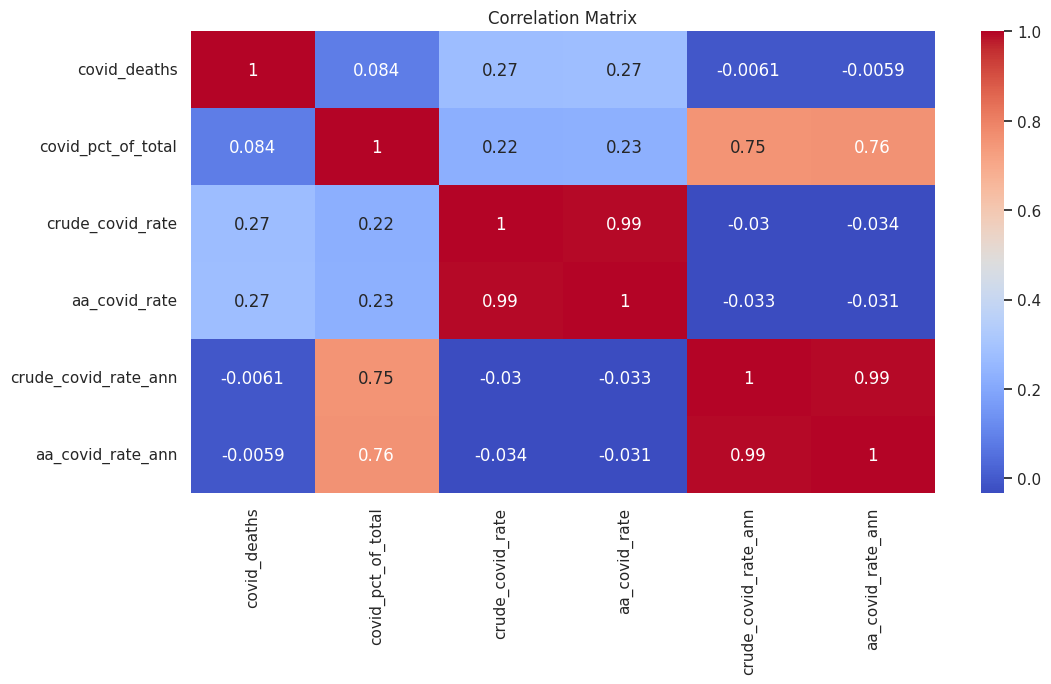

In [12]:
num_cols = df_clean.select_dtypes(include=['number']).columns

plt.figure(figsize=(12,6))
sns.heatmap(df_clean[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [13]:
state_map = {
 'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA','Colorado':'CO',
 'Connecticut':'CT','Delaware':'DE','District of Columbia':'DC','Florida':'FL','Georgia':'GA','Hawaii':'HI',
 'Idaho':'ID','Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS','Kentucky':'KY','Louisiana':'LA',
 'Maine':'ME','Maryland':'MD','Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS',
 'Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV','New Hampshire':'NH','New Jersey':'NJ',
 'New Mexico':'NM','New York':'NY','North Carolina':'NC','North Dakota':'ND','Ohio':'OH','Oklahoma':'OK',
 'Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD',
 'Tennessee':'TN','Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA','Washington':'WA','West Virginia':'WV',
 'Wisconsin':'WI','Wyoming':'WY'
}

if geo_col and target_col:

    plot_df = df_clean.copy()

    # Try mapping directly
    if plot_df[geo_col].dtype == 'object':
        plot_df['state_code'] = plot_df[geo_col].map(state_map)

    # If many missing codes, try Title() version
    if plot_df['state_code'].isna().mean() > 0.4:
        plot_df[geo_col + '_title'] = plot_df[geo_col].astype(str).str.title()
        plot_df['state_code'] = plot_df[geo_col + '_title'].map(state_map)
        plot_df['state_name'] = plot_df[geo_col + '_title']
    else:
        plot_df['state_name'] = plot_df[geo_col]

    # Aggregate with BOTH state code and state name
    plot_agg = (
        plot_df.groupby(['state_code', 'state_name'])[target_col]
        .sum()
        .reset_index()
        .dropna()
    )

    if not plot_agg.empty:
        fig = px.choropleth(
            plot_agg,
            locations='state_code',
            locationmode='USA-states',
            color=target_col,
            scope='usa',
            title=f'USA {target_col} by state',
            hover_data=['state_name', target_col]   # ⭐ REGION NAME NOW INCLUDED
        )
        fig.show()

    else:
        print("Choropleth data not ready — ensure geo_col contains consistent state names.")

else:
    print("Skipping choropleth: geo_col or target_col missing.")
